<a href="https://colab.research.google.com/github/AndresMontesDeOca/NLP_1/blob/main/Desafios/Desafio_2_AndresMontesDeOca_LOTR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.0 MB/s eta 0:00:00


### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [ ]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

In [ ]:
# Posibles bandas
os.listdir("./songs_dataset/")

In [ ]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

In [ ]:
print("Cantidad de documentos:", df.shape[0])

### 1 - Preprocesamiento

In [ ]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [ ]:
# Demos un vistazo
sentence_tokens[:2]

### 2 - Crear los vectores (word2vec)

In [2]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [ ]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [ ]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [ ]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

In [ ]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

### 3 - Entrenar embeddings

In [ ]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

### 4 - Ensayar

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

In [ ]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

In [ ]:
 y ana# Ensayar con una palabra que no está en el vocabulario:
w2v_model.wv.most_similar(negative=["diedaa"])

In [ ]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

In [ ]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

### 5 - Visualizar agrupación de vectores

In [17]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [ ]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [ ]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

In [ ]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

0) Cargamos la primera parte de la trilogia del Senor de los Anillos (La comunidad del anillo)

In [4]:
!pip install -q gdown PyPDF2

import gdown
import PyPDF2
import pandas as pd

pd.set_option('display.max_colwidth', None)

# Descargar el archivo desde Google Drive usando su ID
file_id = '0Bzr5RihQVFTfWndxTG43cVVPcnM'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'comunidad_del_anillo.pdf'
gdown.download(url, output, quiet=False)

# Extraer el texto del PDF
text = ""
with open(output, 'rb') as file:
    reader = PyPDF2.PdfReader(file)
    for page in reader.pages:
        extracted = page.extract_text()
        if extracted:
            text += extracted + " "

# Reemplazar los saltos de línea (renglones del PDF) por espacios
text = text.replace('\n', ' ')

# Dividir el texto en oraciones utilizando el punto
lineas = text.split('.')

df_lotr = pd.DataFrame(lineas, columns=['oracion'])
# Filtrar líneas vacías
df_lotr = df_lotr[df_lotr['oracion'].str.strip() != '']

print(f"Cantidad de oraciones extraídas: {df_lotr.shape[0]}")
df_lotr.head(15)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.1 MB/s eta 0:00:00


Downloading...
From: https://drive.google.com/uc?id=0Bzr5RihQVFTfWndxTG43cVVPcnM
To: /content/comunidad_del_anillo.pdf
100%|██████████| 1.32M/1.32M [00:00<00:00, 176MB/s]


Cantidad de oraciones extraídas: 11107


,oracion
0,"El Señor de los Anillos JRR Tolkien PARTE I: La Comunidad del Anillo PROLOGO 1 De los Hobbits Este libro trata principalmente de los Hobbits, y el lector descubrirá en sus páginas mucho del carácter y algo de la historia de este pueblo"
1,Podrá encontrarse más información en los extractos del Libro Rojo de la Frontera de l Oeste que ya han sido publicados con el título de El Hobbit
2,"El relato tuvo su origen en los primeros capítulos del Libro Rojo, compuesto por Bilbo Bolsón -el primer Hobbit que fue famoso en el mundo entero - y que él tituló Historia de una ida y de una vuelta, pues contaba el viaje de Bilbo hacia el Este y la vuelta, aventura que más tarde enredaría a todos los Hobbits en los importantes acontecimientos que aquí se relatan"
3,"No obstante, muchos querrán saber desde un principio algo más de este pueblo notable y quizás algunos no tengan el libro anterior"
4,"Para esos lectores se han reunido aquí algunas notas sobre los puntos más importantes de la tradición hobbit, y se recuerda brevemente la primera aventura"
5,"Los Hobbits son un pueblo sencillo y mu y antiguo, más numeroso en tiempos remotos que en la actualidad"
6,"Amaban la paz, la tranquilidad y el cultivo de la buena tierra, y no había para ellos paraje mejor que un campo bien aprovechado y bien ordenado"
7,"No entienden ni entendían ni gustan de maqu inarias más complicadas que una fragua, un molino de agua o un telar de mano, aunque fueron muy hábiles con toda clase de herramientas"
8,"En otros tiempos desconfiaban en general de la Gente Grande, como nos llaman y ahora nos eluden con terror y es difícil encontrarlos"
9,"Tienen el oído agudo y la mirada penetrante, y aunque engordan fácilmente y nunca se apresuran si no es necesario, se mueven con agilidad y destreza"


1) Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)

In [6]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence
from gensim.models import Word2Vec

# 1. Preprocesamiento: Convertir oraciones a secuencias de palabras
sentence_tokens_lotr = []
for _, row in df_lotr.iterrows():
    sentence_tokens_lotr.append(text_to_word_sequence(row['oracion']))

# 2. Crear el modelo Word2Vec usando el nuevo corpus
w2v_model_lotr = Word2Vec(min_count=5, # con un min_count de 7 me baja la cantidad de palabras distintas un 20% aprox
                          window=5, # Le damos una ventana mas grande, stajndard para textos narrativos
                          vector_size=150, # 300 e smucho para un corpus de un solo libro
                          negative=20,
                          workers=1,
                          sg=1)

# Construir el vocabulario
w2v_model_lotr.build_vocab(sentence_tokens_lotr)
print("Cantidad de words distintas en el corpus LotR:", len(w2v_model_lotr.wv.index_to_key))

# 3. Entrenar los embeddings
w2v_model_lotr.train(sentence_tokens_lotr,
                     total_examples=w2v_model_lotr.corpus_count,
                     epochs=20,
                     compute_loss=True,
                     callbacks=[callback()])

Cantidad de words distintas en el corpus LotR: 3318
Loss after epoch 0: 2161868.25
Loss after epoch 1: 1607848.25
Loss after epoch 2: 1517298.5
Loss after epoch 3: 1472651.5
Loss after epoch 4: 1461939.5
Loss after epoch 5: 1409812.0
Loss after epoch 6: 1390246.0
Loss after epoch 7: 1380774.0
Loss after epoch 8: 1367508.0
Loss after epoch 9: 1363269.0
Loss after epoch 10: 1356846.0
Loss after epoch 11: 1324715.0
Loss after epoch 12: 1314780.0
Loss after epoch 13: 1303972.0
Loss after epoch 14: 1305244.0
Loss after epoch 15: 1297792.0
Loss after epoch 16: 1301694.0
Loss after epoch 17: 1293600.0
Loss after epoch 18: 1296170.0
Loss after epoch 19: 1295742.0


(2252104, 3642500)

- min_count: Si lo seteamos en 5 me encuentra unas 3300 palabras. Probamos un valor mas restrictivo de 7, y nos baja a unas 2800
- window: Al ser un texto narrativo le damos una ventana mas grande para que aprenda mejor del contexto. El estandard para estos tipos de documentos de 4 o 5, optamos por 5
- vector_size: Por lo que pude investigar, para un corpus pequeno de un libro solo, el valor sugerido deberia estar entre 100 y 200, dejamos 150
- El resto de los hipeparametros los dejamos igual

2) Elegir términos de interés y buscar términos más similares y menos similares.

In [15]:
# Palabras que MÁS se relacionan con 'anillo':
print("Palabras más similares a 'anillo':")
display(w2v_model_lotr.wv.most_similar(positive=["anillo"], topn=5))

# Palabras que MÁS se relacionan con 'frodo':
print("\nPalabras más similares a 'sombra':")
display(w2v_model_lotr.wv.most_similar(positive=["sombra"], topn=5))

# Palabras que MÁS se relacionan con 'elfo':
print("\nPalabras más similares a 'elfo':")
display(w2v_model_lotr.wv.most_similar(positive=["elfo"], topn=5))

# Palabras que MÁS se relacionan con 'enano':
print("\nPalabras más similares a 'enano':")
display(w2v_model_lotr.wv.most_similar(positive=["enano"], topn=5))

# Palabras que MÁS se relacionan con 'Gandalf':
print("\nPalabras más similares a 'Gandalf':")
display(w2v_model_lotr.wv.most_similar(positive=["gandalf"], topn=5))

# Palabras que MENOS se relacionan con 'hobbit':
print("\nPalabras menos similares a 'hobbits':")
display(w2v_model_lotr.wv.most_similar(negative=["hobbits"], topn=5))

Palabras más similares a 'anillo':


[('dedo', 0.6316521167755127),
 ('unico', 0.5804585814476013),
 ('bolsillo', 0.5427118539810181),
 ('enemigo', 0.5354709029197693),
 ('soberano', 0.5314145088195801)]


Palabras más similares a 'sombra':


[('oscura', 0.581204354763031),
 ('horizonte', 0.550757110118866),
 ('negra', 0.5387287735939026),
 ('vasta', 0.5277986526489258),
 ('descendido', 0.5260449647903442)]


Palabras más similares a 'elfo':


...

[('hacha', 0.6548425555229187),
 ('thorin', 0.6318099498748779),
 ('glóin', 0.6149325370788574),
 ('mithril', 0.6061191558837891),
 ('escudo', 0.5926992893218994)]


Palabras más similares a 'Gandalf':


[('mago', 0.4991503953933716),
 ('gravemente', 0.49483639001846313),
 ('tratando', 0.4945753514766693),
 ('tristemente', 0.49390241503715515),
 ('ay', 0.4916728734970093)]


Palabras menos similares a 'hobbits':


[('yo', 0.014477395452558994),
 ('también', -0.006916401907801628),
 ('noche', -0.009583179838955402),
 ('¡el', -0.013005303218960762),
 ('exclamó', -0.01850929483771324)]

- Todas las palabras similares buscadas tienen mucho sentido, pero no pareciera ser asi con la menos similar que buscamos para Hobbbit

3) Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.

In [20]:
import plotly.express as px

# Reducir dimensiones a 2D utilizando la función previamente definida
vecs_lotr, labels_lotr = reduce_dimensions(w2v_model_lotr, num_dimensions=2)

# Graficar los embeddings proyectados
MAX_WORDS = 200
fig = px.scatter(x=vecs_lotr[:MAX_WORDS,0],
                 y=vecs_lotr[:MAX_WORDS,1],
                 text=labels_lotr[:MAX_WORDS],
                 title="Embeddings 2D - La Comunidad del Anillo")

fig.update_traces(textposition='top center')
fig.show(renderer="colab")

- Setemaos MAX_WORDS en 200 para ver la ubicacion de los embeddings de las top 200 palabras

4) Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

- Se observa que los nombres de los personajes de la comunidad (Gandalf, Sam, Aragorn, Pipin, Merry, Gimli, etc) estan muy juntos, cerca de los valores -2 y 25 de los ejes x e y

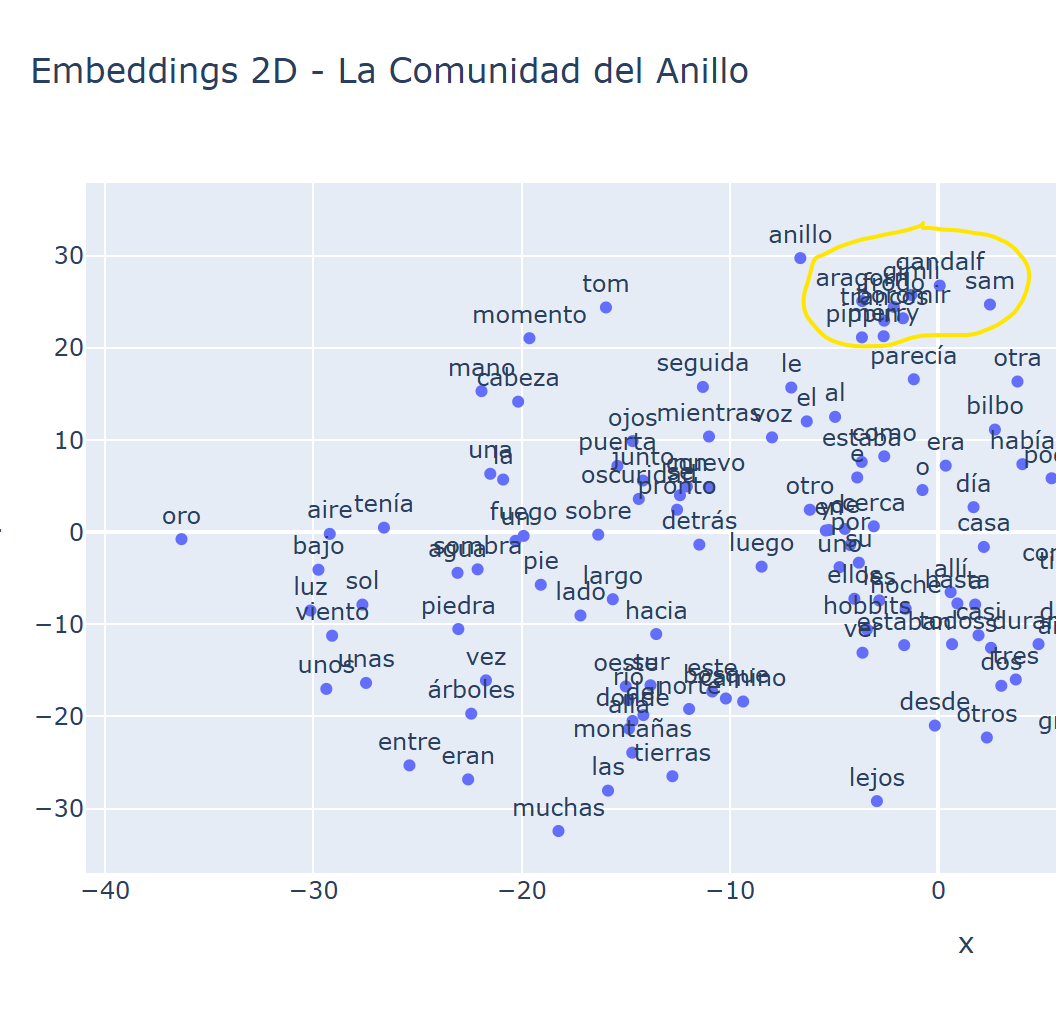


- Tambien se observa lo que parece ser otro "cluster" de lugares o ubicaciones (Oeste, Este, Sur, Montana, Bosuqe, Camino, Rio), cerca de las coordenadas -15, -20
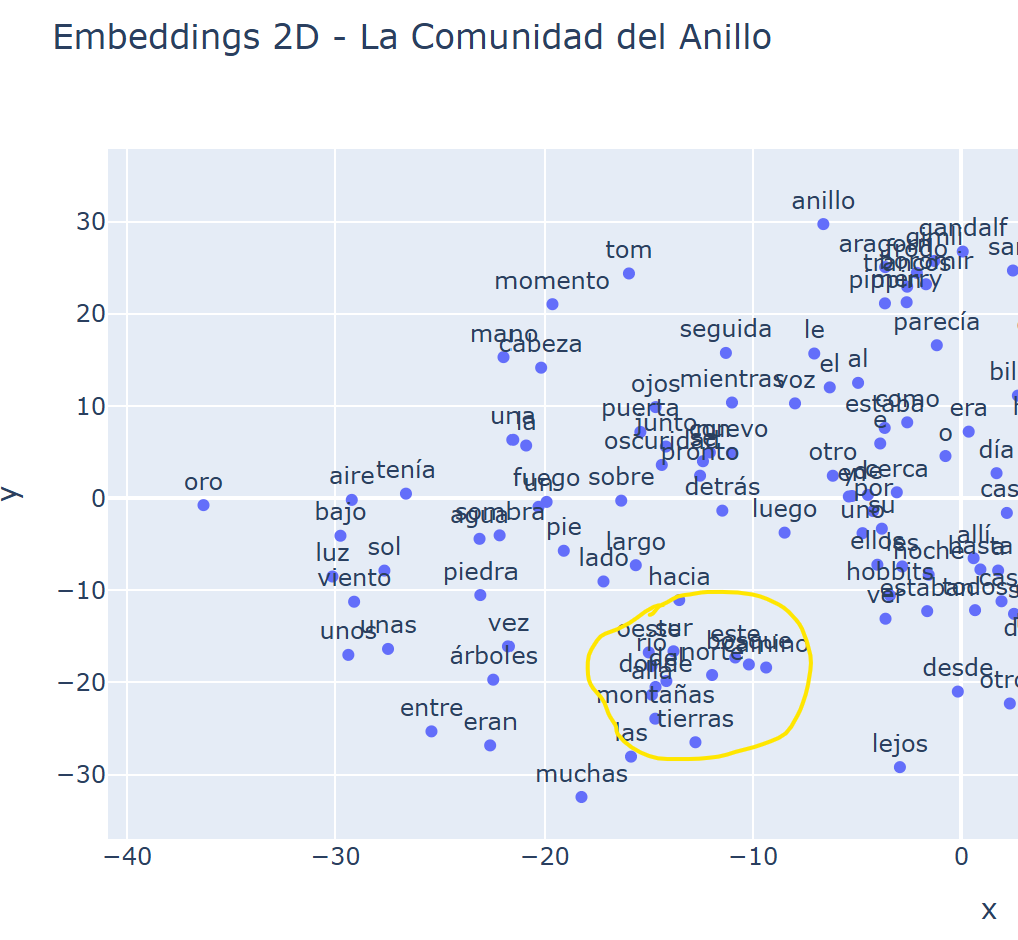